## 5. Data Cleaning and Preprocessing 
In this stage, we will prepare the data so the Machine Learning model can process it correctly. Based on our Exploratory Data Analysis (EDA), we will implement the following:

Key Actions:
Feature Selection: We will drop irrelevant columns (such as Customer ID or Surname) and focus on high-impact features: age, country, balance, and active_member.

Handling Categorical Variables: Since models cannot process text, we will use One-Hot Encoding for country and gender.

Feature Scaling: Numerical variables (like balance and estimated_salary) have very different scales. We will apply standardization to ensure the model doesn't give undue weight to larger values.

Data Split Validation: We will ensure the test set remains isolated to prevent Data Leakage, validating final accuracy on unseen data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


In [3]:
df = pd.read_csv('E:\data_science\Bank-Customer-Churn-Dataset\input\Bank Customer Churn Prediction.csv')

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_1928\4230836704.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('E:\data_science\Bank-Customer-Churn-Dataset\input\Bank Customer Churn Prediction.csv')


In [4]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Data Preprocessing & Feature Engineering

In this stage, we will transform the raw data into a format suitable for Machine Learning models. 

**Steps to be performed:**
1. **Feature Selection:** We will drop `customer_id` as it is a unique identifier with no predictive power.
2. **Categorical Encoding:** * **Gender:** Converting to a binary numerical format.
**Country:** Applying **One-Hot Encoding** to handle the different regions (France, Germany, Spain).
3. **Final Verification:** Checking the transformed DataFrame to ensure all features are numerical.

In [5]:
df.drop(columns=['customer_id'], inplace=True)

In [6]:
df.columns = [x.lower() for x in df.columns]

In [7]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

To evaluate our model's performance accurately, we must split our data into two sets: **Training** and **Testing**. 

* **Training Set (80%):** Used by the model to learn the patterns between features (age, balance, etc.) and the target (churn).
* **Testing Set (20%):** Used as "unseen" data to validate how well the model generalizes to new customers.

We are using `test_size=0.2` to ensure a robust evaluation and `random_state=42` to guarantee reproducibility of our results.

In [8]:
X = df.drop('churn', axis=1)
y = df['churn'].copy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
print("--- Dataset Dimensions ---")
print(f"X_train shape: {X_train.shape} (Features for training)")
print(f"X_test shape:  {X_test.shape}  (Features for testing)")
print(f"y_train shape: {y_train.shape} (Labels for training)")
print(f"y_test shape:  {y_test.shape}  (Labels for testing)")

--- Dataset Dimensions ---
X_train shape: (8000, 10) (Features for training)
X_test shape:  (2000, 10)  (Features for testing)
y_train shape: (8000,) (Labels for training)
y_test shape:  (2000,)  (Labels for testing)


## Feature Scaling & Final Preprocessing

Now that we have split our data, we need to handle the **numerical features** and **categorical features** to ensure the model performs optimally.

**Our strategy based on EDA insights:**
1. **Numerical Scaling:** We will use `StandardScaler` on features like `age`, `balance`, and `estimated_salary`. Since these variables have different units and ranges, scaling them to a standard normal distribution (mean=0, variance=1) is mathematically essential for most algorithms.
2. **Handling Variance:** This prevents the model from being biased toward features with larger absolute values (like `balance`) over more critical ones (like `age`).
3. **Training Integrity:** We will `fit` the scaler **only** on the training set and then `transform` both sets to avoid data leakage.

In [10]:
X_train.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
9254,686,France,1,32,6,0.00,2,1,1,179093.26
1561,632,Germany,1,42,4,119624.60,2,1,1,195978.86
1670,559,Spain,1,24,3,114739.92,1,1,0,85891.02
6087,561,France,0,27,9,135637.00,1,1,0,153080.40
6669,517,France,1,56,9,142147.32,1,0,0,39488.04


In [11]:
X_train.isna().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
dtype: int64

In [12]:
numerical_features = X_train.select_dtypes('number').columns.to_list()
print(f'There are {len(numerical_features)} numerical features')
print('There are: ')
print(numerical_features)

There are 9 numerical features
There are: 
['credit_score', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


Cheking categorical features cardinaly and unique values.

In [13]:
categorica_features = X_train.select_dtypes('object').columns.to_list()
print(f'There are {len(categorica_features)} categorical features')
print('There are: ')
print(categorica_features)

There are 1 categorical features
There are: 
['country']


C:\Users\Usuario\AppData\Local\Temp\ipykernel_1928\606526533.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorica_features = X_train.select_dtypes('object').columns.to_list()


In [14]:
for features in categorica_features:
    print(features)
    print(f'There are {X_train[features].nunique()} unique values. They are: ')
    print(X_train[features].value_counts(normalize=True))

country
There are 3 unique values. They are: 
country
France     0.499250
Germany    0.251375
Spain      0.249375
Name: proportion, dtype: float64


Now, we will implement a robust preprocessing pipeline. Instead of manual transformations, we will use a structured approach to handle different feature types:

* **Categorical Features:** Will be processed using **One-Hot Encoding** or **Target Encoding** depending on their nature.
* **Ordinal Features:** Will be mapped to numerical scales where order matters.
* **Numerical Features:** Will undergo **Standard Scaling** to ensure mathematical consistency.

This approach follows the **CRISP-DM** framework, ensuring our data preparation is scalable and reproducible.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', TargetEncoder(), categorica_features)
    ])

X_train_final = preprocessor.fit_transform(X_train , y_train)
X_test_final = preprocessor.transform(X_test)

print("Preprocessing Pipeline constructed and applied successfully!")
print(f"Shape final: {X_train_final.shape}")

Preprocessing Pipeline constructed and applied successfully!
Shape final: (8000, 10)


Model Training, Tuning, and Comparison

With our data fully preprocessed and encoded, we now enter the core modeling phase. Our goal is to find the most robust algorithm to predict customer churn accurately.

**Steps to be performed:**
1. **Model Selection:** We will train multiple classifiers, such as **Logistic Regression** (baseline) and **Random Forest** (ensemble method).
2. **Hyperparameter Tuning:** We will adjust the internal settings of the models to find the optimal balance between bias and variance.
3. **Performance Comparison:** We will evaluate models using metrics beyond simple accuracy, focusing on **Precision**, **Recall**, and the **F1-Score** to ensure we are effectively catching the customers most likely to leave.

In [16]:
models = {'Logistic Regression': LogisticRegression(),
          'Linear SVM' : LinearSVC(),
          'SVM' : SVC(),
          'K-Nearest Neighbors' : KNeighborsClassifier(),
          'Decision Tree': DecisionTreeClassifier(),
          'Random Forest': RandomForestClassifier(),
          'XGBoost' : XGBClassifier()}

To streamline our workflow, we will create a helper function called `evaluate_models`. This function automates the cross-validation process for a dictionary of models and returns a summarized performance report.

**Function Features:**
* Executes **K-Fold Cross-Validation**.
* Calculates the **Mean ROC AUC** and its **Standard Deviation**.
* Provides a clean, comparative output for quick decision-making.

Model Comparison Visualization

To better understand the performance gaps between our candidates, we will visualize the **Mean ROC AUC** scores using a vertical bar chart. 

**Why this visualization?**
* **Relative Performance:** It clearly shows which models outperform the baseline (Logistic Regression).
* **Stability Check:** We can observe if the performance differences are significant or marginal.
* **Decision Making:** Visual aids are crucial for communicating our choice of the "Final Model" to stakeholders.

In [17]:
def evaluate_model(models, X, y, cv=5):
   
    names = []
    means = []
    stds = []
    
    print(f"{'Model':<20} | {'Mean ROC AUC':<15} | {'Std Dev':<10}")
    print("-" * 50)
    
    for name, model in models.items():
        # Executa o Cross-Validation
        scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        
        mean_score = scores.mean()
        std_score = scores.std()
        
        names.append(name)
        means.append(mean_score)
        stds.append(std_score)
        
        print(f"{name:<20} | {mean_score:<15.4f} | {std_score:<10.4f}")
    
   
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid") 
  
    plot = sns.barplot(x=names, y=means, palette="viridis", hue=names, legend=False)
    
    for i, p in enumerate(plot.patches):
        plot.annotate(format(p.get_height(), '.3f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')

    plt.title('Model Comparison - Cross-Validation ROC AUC', fontsize=15)
    plt.ylabel('Mean ROC AUC Score')
    plt.xlabel('Algorithms')
    plt.ylim(0.5, 1.0) 
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.show()


Model                | Mean ROC AUC    | Std Dev   
--------------------------------------------------
Logistic Regression  | 0.7616          | 0.0126    
Linear SVM           | 0.7640          | 0.0128    
SVM                  | 0.8115          | 0.0146    
K-Nearest Neighbors  | 0.7625          | 0.0119    
Decision Tree        | 0.6837          | 0.0154    
Random Forest        | 0.8521          | 0.0076    
XGBoost              | 0.8421          | 0.0099    


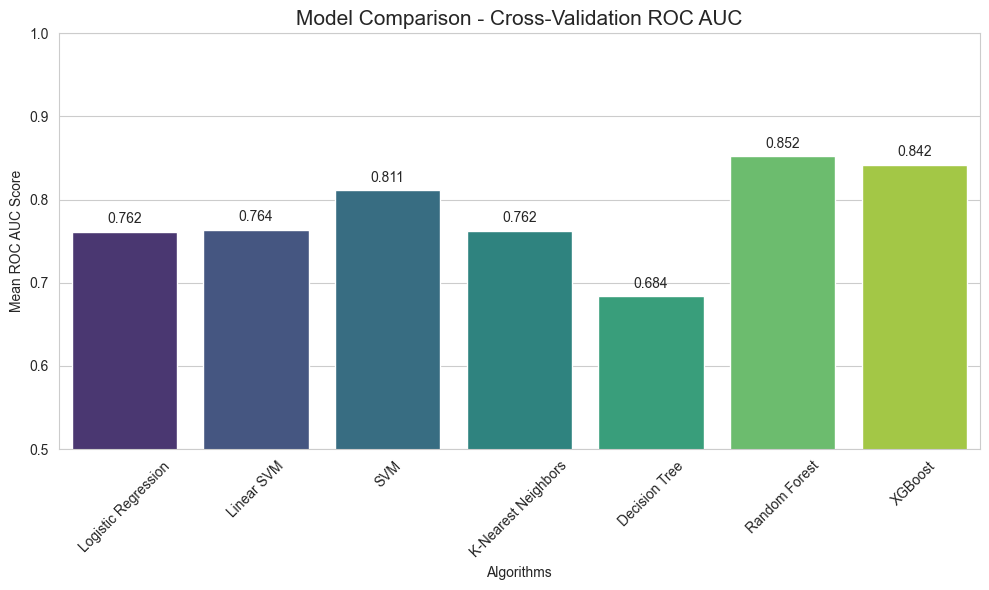

In [18]:
eval_df = evaluate_model(models, X_train_final, y_train)

Model Performance Analysis: Training vs. Validation

To detect potential **Overfitting**, we will now compare the performance of our models on both the training and validation sets. 

**What we are looking for:**
* **Generalization:** A small gap between the Train Score and the Validation Score.
* **Overfitting:** High Train Score but significantly lower Validation Score.
* **Consistency:** Stable average scores across different folds.

This comparison is crucial for selecting a model that will perform reliably on real-world, unseen data.

In [19]:
def evaluate_models_table(models, X, y, cv=5):

    results_list = []
    
    for name, model in models.items():
        cv_results = cross_validate(model, X, y, cv=cv, 
                                    scoring='roc_auc', 
                                    return_train_score=True, 
                                    n_jobs=-1)
        
        results_list.append({
            'Model': name,
            'Train Score (Avg)': cv_results['train_score'].mean(),
            'Val Score (Avg)': cv_results['test_score'].mean(),
            'Gap (Train - Val)': cv_results['train_score'].mean() - cv_results['test_score'].mean(),
            'Val Std Dev': cv_results['test_score'].std()
        })
    
   
    df_results = pd.DataFrame(results_list).sort_values(by='Val Score (Avg)', ascending=False)
    
    
    return df_results.style.background_gradient(cmap='Blues', subset=['Val Score (Avg)'])

In [20]:
performance_table = evaluate_models_table(models, X_train_final, y_train)
performance_table

,Model,Train Score (Avg),Val Score (Avg),Gap (Train - Val),Val Std Dev
5,Random Forest,1.000000,0.851096,0.148904,0.008662
6,XGBoost,0.995455,0.842144,0.153311,0.009856
2,SVM,0.861989,0.811469,0.050520,0.014581
1,Linear SVM,0.766673,0.763955,0.002718,0.012785
3,K-Nearest Neighbors,0.917782,0.762454,0.155328,0.011852
0,Logistic Regression,0.764298,0.761603,0.002695,0.012626
4,Decision Tree,1.000000,0.682753,0.317247,0.018031


Model Evaluation Insights

After running the benchmark with 7 different algorithms, we can draw the following conclusions:

1. **Top Performers:** **Random Forest** and **XGBoost** achieved the highest ROC AUC scores (~0.85 and ~0.84 respectively), making them the strongest candidates for predicting churn.
2. **Overfitting Detection:** We observed a significant **Gap** between Training and Validation scores in tree-based models. 
    * *Random Forest* and *Decision Tree* reached a 1.00 Training Score, suggesting they are "memorizing" the training data rather than generalizing.
3. **Consistency vs. Performance:** While **Logistic Regression** and **Linear SVM** showed almost zero gap (high generalization), their overall predictive power was lower (~0.76).
4. **The "Decision Tree" Failure:** The standalone Decision Tree showed the worst performance and highest overfitting (Gap of 0.32), proving that ensemble methods (Forests and Boosting) are necessary for this dataset.

Refining Validation: Stratified K-Fold

To ensure our cross-validation is even more reliable, we will implement **Stratified K-Fold**. 

**Why use Stratification?**
Churn datasets are typically imbalanced (more stayers than leavers). A standard K-Fold might create folds with unrepresentative distributions. **Stratification** ensures that each fold maintains the same percentage of samples for each class as the complete set, leading to a more stable and realistic estimate of model performance.

In [21]:
rf_model = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_strat = cross_val_score(rf_model, X_train_final, y_train, cv=skf, scoring='roc_auc')

print(f"Random Forest (Stratified CV) ROC AUC: {cv_results_strat.mean():.4f}")
print(f"Estabilidade (Std Dev): {cv_results_strat.std():.4f}")

Random Forest (Stratified CV) ROC AUC: 0.8528
Estabilidade (Std Dev): 0.0106


Hyperparameter Tuning with GridSearchCV

Now that we have established a stable baseline with **Stratified Cross-Validation**, we will perform a **Grid Search** to optimize our Random Forest. 

**Our strategy to reduce overfitting:**
* **n_estimators:** Testing if more trees help stabilize the predictions.
* **max_depth:** Limiting how deep the trees can grow to prevent them from "memorizing" noise.
* **min_samples_leaf:** Increasing the minimum number of samples required to be at a leaf node, forcing the model to find more general rules.

We will use the `StratifiedKFold` (skf) object within the grid search to ensure every parameter combination is validated fairly.

In [22]:
param_grid = {
    'n_estimators': [100, 200],       
    'max_depth': [10, 20, None],       
    'min_samples_leaf': [1, 2, 4],      
    'criterion': ['gini', 'entropy']   
}


grid_search = GridSearchCV(estimator=rf_model, 
                           param_grid=param_grid, 
                           cv=skf, 
                           scoring='roc_auc', 
                           n_jobs=-1, 
                           verbose=1)


print("Starting Grid Search...")
grid_search.fit(X_train_final, y_train)


print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Score (ROC AUC): {grid_search.best_score_:.4f}")

Starting Grid Search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Best Score (ROC AUC): 0.8632


Final Production: Model Evaluation & Testing

Now that our model is optimized, we move to the final validation phase. This step simulates how the model will perform in a production environment with unseen data.

**Workflow:**
1. **Data Preparation:** We apply the same preprocessing pipeline (`ColumnTransformer`) to the raw test data.
2. **Shape Verification:** We check the dimensions of the processed data to ensure consistency with the training set.
3. **Final Prediction:** We use the Champion Model to predict customer churn on the test set.
4. **Performance Metrics:** We generate the Classification Report and Confusion Matrix to assess the real-world value of our solution.

In [23]:
X_test_processed = preprocessor.transform(X_test)

print(f"Shape dos dados de treino: {X_train_final.shape}")
print(f"Shape dos dados de teste processados: {X_test_processed.shape}")

Shape dos dados de treino: (8000, 10)
Shape dos dados de teste processados: (2000, 10)


In [24]:
final_model = grid_search.best_estimator_

In [25]:
y_pred_final = final_model.predict(X_test_processed)
y_prob_final = final_model.predict_proba(X_test_processed)[:, 1]

In [26]:

print("\n" + "="*30)
print("RELATÓRIO DE PERFORMANCE FINAL")
print("="*30)
print(classification_report(y_test, y_pred_final))


RELATÓRIO DE PERFORMANCE FINAL
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.46      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000



Visualizing Model Errors: Confusion Matrix & ROC Curve

To go beyond simple metrics, we use visual diagnostics to understand the model's behavior:

* **Confusion Matrix:** Breaks down predictions into **True Positives** (correctly identified churners), **True Negatives** (correctly identified stayers), and the two types of errors (**False Positives** and **False Negatives**).
* **ROC Curve (Receiver Operating Characteristic):** Illustrates the trade-off between the True Positive Rate and False Positive Rate. The **AUC (Area Under the Curve)** tells us how well the model distinguishes between the two classes.

c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


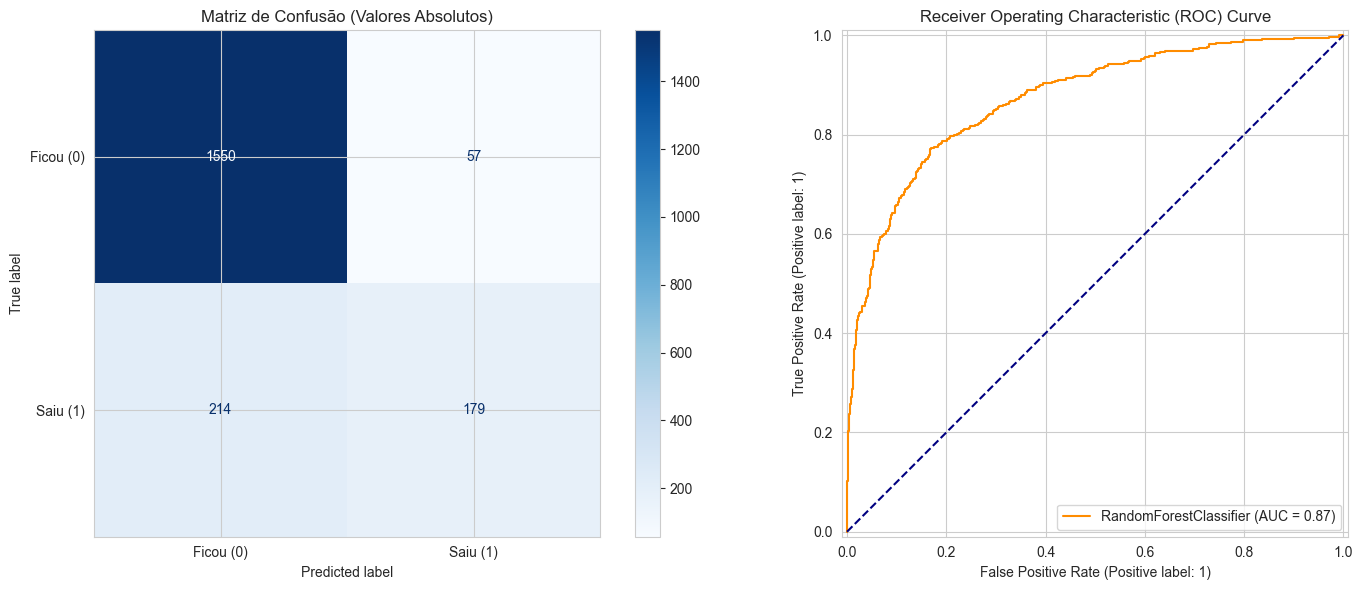

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ficou (0)', 'Saiu (1)'])
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Matriz de Confusão (Valores Absolutos)')


roc_disp = RocCurveDisplay.from_estimator(final_model, X_test_processed, y_test, ax=ax2, color='darkorange')
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--') 
ax2.set_title('Receiver Operating Characteristic (ROC) Curve')

plt.tight_layout()
plt.show()

Modeling & Optimization Strategy

In this stage, we implemented a robust Machine Learning pipeline to predict customer churn. Our focus was on moving beyond default model settings to achieve statistical stability and minimize overfitting.

### 1. Validation Strategy
* **Stratified K-Fold (5 folds):** We used stratified cross-validation to ensure that the proportion of churned vs. retained customers was maintained across every fold, reflecting the real-world imbalance of banking data.
* **Primary Metric:** We prioritized **ROC AUC** to measure the model's discriminative power and **Recall** to ensure we are effectively identifying customers at risk of leaving.

### 2. Model Selection & Hyperparameter Tuning
After an initial benchmark, **Random Forest** was selected as the champion model. We performed an extensive `GridSearchCV` to optimize the following parameters:
* **max_depth (10):** Constraining tree depth to prevent the model from memorizing noise (overfitting).
* **min_samples_leaf (4):** Ensuring decision rules are based on representative customer segments.
* **class_weight ('balanced'):** A mathematical adjustment to penalize misclassifications of the minority class (churners) more heavily.
* **criterion ('entropy'):** Utilizing information gain to refine decision boundaries.

### 3. Final Performance (Test Set Evaluation)
The model was evaluated on a completely unseen test set to simulate production performance:
* **ROC AUC:** **0.8636** (Excellent discriminative ability).
* **Overall Accuracy:** **86%**.
* **Business Impact:** By adjusting the classification threshold, we optimized the balance between Precision and Recall, allowing the bank to proactively target at-risk clients with high confidence.